DEVICE: cuda
Loading model...


D:\PipCache\ipykernel_21232\476374200.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_state = torch.load(MODEL_PATH, map_location=DEVICE)


Loaded with encoder: timm-mobilenetv3_large_100
Found 16 internet images.


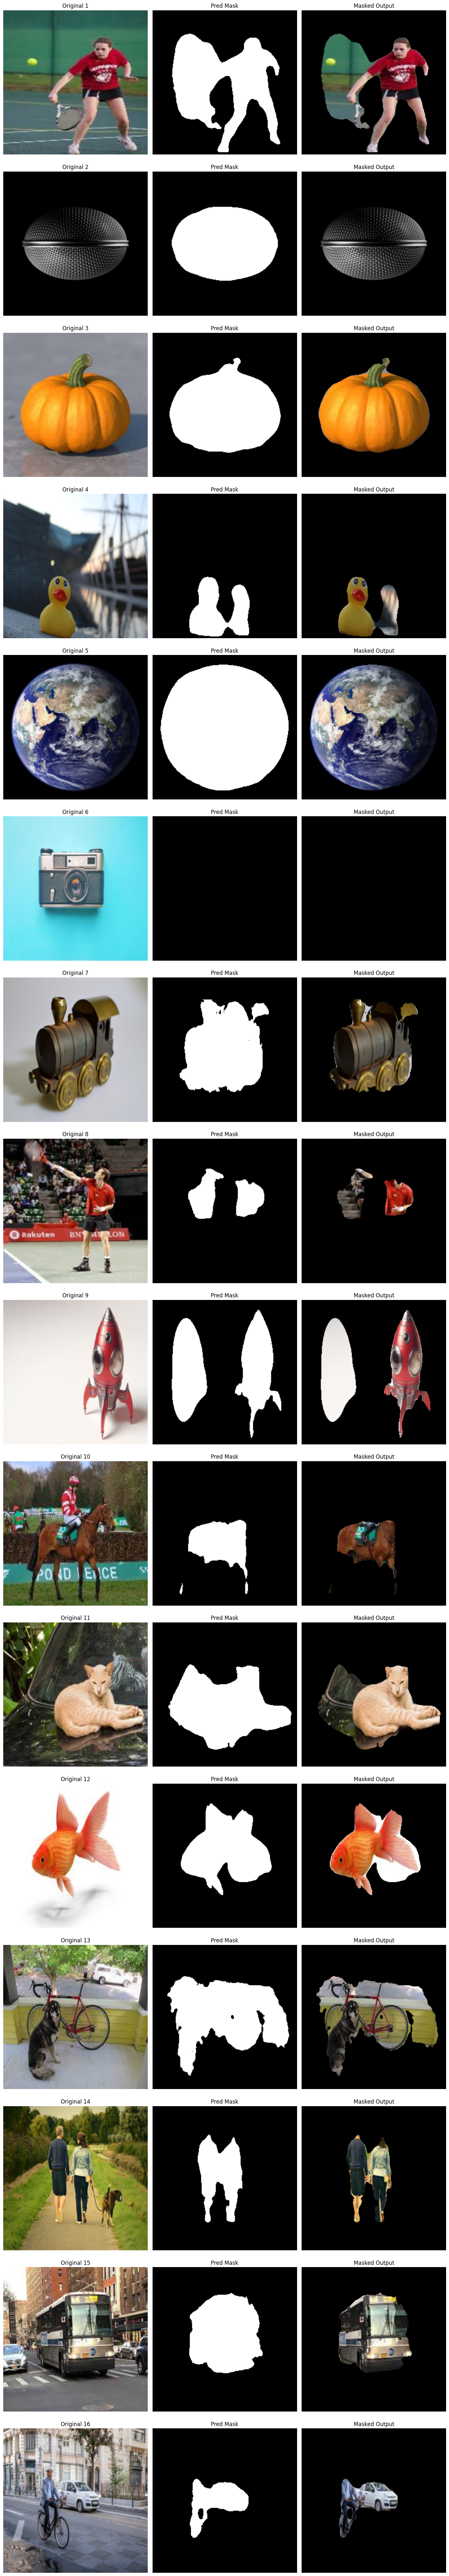

✔ DONE! All internet test images processed.
Outputs saved to: D:\coco2017\internet_test_outputs


In [3]:
# ===============================================================
# INTERNET IMAGE TESTING — 20 IMAGES (image1.jpg ... image20.jpg)
# Works with your Auto-Tuned model (best_auto.pth)
# ===============================================================

import os
from glob import glob
from PIL import Image
import numpy as np
import torch
import torchvision.transforms as T
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp

# ------------------------------------------------------------
# PATHS (your exact folder)
# ------------------------------------------------------------
TEST_DIR = r"D:\coco2017\internet_test_images"
MODEL_PATH = r"D:\coco2017\models_auto\best_auto.pth"
OUT_DIR = r"D:\coco2017\internet_test_outputs"

os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# ------------------------------------------------------------
# Load model safely (encoder auto-detected from checkpoint)
# ------------------------------------------------------------
print("Loading model...")

model_state = torch.load(MODEL_PATH, map_location=DEVICE)
# Try all best possible encoders
possible_encoders = [
    "timm-mobilenetv3_large_100",
    "mobilenet_v2",
    "efficientnet-b0"
]

loaded = False
for enc in possible_encoders:
    try:
        model = smp.Unet(
            encoder_name=enc,
            encoder_weights=None,
            in_channels=3,
            classes=1
        ).to(DEVICE)
        model.load_state_dict(model_state)
        print("Loaded with encoder:", enc)
        loaded = True
        break
    except:
        continue

if not loaded:
    raise RuntimeError("Could not load model with any known encoder.")

model.eval()

# ------------------------------------------------------------
# Find test images
# ------------------------------------------------------------
test_images = sorted(glob(os.path.join(TEST_DIR, "*.jpg")))
print(f"Found {len(test_images)} internet images.")

if len(test_images) == 0:
    raise RuntimeError("❌ ERROR: No .jpg images found in TEST_DIR. Check folder path.")

# ------------------------------------------------------------
# Transform
# ------------------------------------------------------------
IMG_SIZE = 256
tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

raw_resize = T.Resize((IMG_SIZE, IMG_SIZE))

# ------------------------------------------------------------
# Run inference on all test images
# ------------------------------------------------------------
fig, ax = plt.subplots(len(test_images), 3, figsize=(14, 5 * len(test_images)))

for idx, ip in enumerate(test_images):
    orig = Image.open(ip).convert("RGB")
    orig_resized = np.array(raw_resize(orig))

    ten = tf(orig).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = torch.sigmoid(model(ten))[0,0].cpu().numpy()

    binmask = (pred > 0.5).astype(np.uint8)
    masked = np.zeros_like(orig_resized)
    masked[binmask == 1] = orig_resized[binmask == 1]

    # Save outputs
    Image.fromarray(orig_resized).save(f"{OUT_DIR}/orig_{idx+1}.png")
    Image.fromarray((binmask*255).astype(np.uint8)).save(f"{OUT_DIR}/mask_{idx+1}.png")
    Image.fromarray(masked).save(f"{OUT_DIR}/masked_{idx+1}.png")

    # Show on notebook
    ax[idx][0].imshow(orig_resized); ax[idx][0].set_title(f"Original {idx+1}"); ax[idx][0].axis("off")
    ax[idx][1].imshow(binmask*255, cmap="gray"); ax[idx][1].set_title("Pred Mask"); ax[idx][1].axis("off")
    ax[idx][2].imshow(masked); ax[idx][2].set_title("Masked Output"); ax[idx][2].axis("off")

plt.tight_layout()
plt.show()

print("✔ DONE! All internet test images processed.")
print("Outputs saved to:", OUT_DIR)
